# CSE445 Project Presentation

#Title: Prediction of Points Table of a Football League Using Machine Learning

#Group: 01

#Section : 04

#Group Members:
##(1) Abdullah Al Hasan (ID: 1831362042),
##(2) Jannatul Ferdous (ID: 2031530642),
##(3) Adib Salahuddin (ID: 2111122642),
##(4) Jonak Bhowmik (ID: 2211148642)

# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports and file read

In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# !pip install lime
import lime
from lime import lime_tabular

from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

In [66]:
# path = "premier-player-23-24.csv"
path = "/content/drive/MyDrive/Dataset/premier-player-23-24.csv"
df_stats = pd.read_csv(path)
print('Number of rows: ', df_stats.shape[0])
print('Number of columns: ', df_stats.shape[1])

Number of rows:  580
Number of columns:  34


In [67]:
# path = "matches.csv"
path = "/content/drive/MyDrive/Dataset/matches.csv"
df_match = pd.read_csv(path)
print('Number of rows: ', df_match.shape[0])
print('Number of columns: ', df_match.shape[1])

Number of rows:  760
Number of columns:  28


# Task 1: Data Preprocessing

## Dataset Analysis and Visualization

In [68]:
df_1 = df_stats.copy()

In [69]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       580 non-null    object 
 1   Nation       580 non-null    object 
 2   Pos          580 non-null    object 
 3   Age          580 non-null    float64
 4   MP           580 non-null    int64  
 5   Starts       580 non-null    int64  
 6   Min          580 non-null    float64
 7   90s          580 non-null    float64
 8   Gls          580 non-null    float64
 9   Ast          580 non-null    float64
 10  G+A          580 non-null    float64
 11  G-PK         580 non-null    float64
 12  PK           580 non-null    float64
 13  PKatt        580 non-null    float64
 14  CrdY         580 non-null    float64
 15  CrdR         580 non-null    float64
 16  xG           580 non-null    float64
 17  npxG         580 non-null    float64
 18  xAG          580 non-null    float64
 19  npxG+xAG

In [70]:
df_1.isnull().sum()

,0
Player,0
Nation,0
Pos,0
Age,0
MP,0
Starts,0
Min,0
90s,0
Gls,0
Ast,0


In [71]:
df_1.drop_duplicates()

,Player,Nation,Pos,Age,MP,Starts,Min,90s,Gls,Ast,...,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Team
0,Rodri,es ESP,MF,27.0,34,34,2931.0,32.6,8.0,9.0,...,0.28,0.52,0.25,0.52,0.12,0.12,0.24,0.12,0.24,Manchester City
1,Phil Foden,eng ENG,"FW,MF",23.0,35,33,2857.0,31.7,19.0,8.0,...,0.25,0.85,0.60,0.85,0.33,0.26,0.59,0.33,0.59,Manchester City
2,Ederson,br BRA,GK,29.0,33,33,2785.0,30.9,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Manchester City
3,Julián Álvarez,ar ARG,"MF,FW",23.0,36,31,2647.0,29.4,11.0,8.0,...,0.27,0.65,0.31,0.58,0.44,0.22,0.66,0.39,0.61,Manchester City
4,Kyle Walker,eng ENG,DF,33.0,32,30,2767.0,30.7,0.0,4.0,...,0.13,0.13,0.00,0.13,0.01,0.09,0.10,0.01,0.10,Manchester City
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,Sam Curtis,ie IRL,DF,17.0,1,0,28.0,0.3,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sheffield United
576,Daniel Jebbison,eng ENG,FW,19.0,1,0,21.0,0.2,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sheffield United
577,Antwoine Hackford,eng ENG,FW,19.0,2,0,13.0,0.1,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sheffield United
578,Sydie Peck,eng ENG,MF,18.0,1,0,10.0,0.1,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Sheffield United


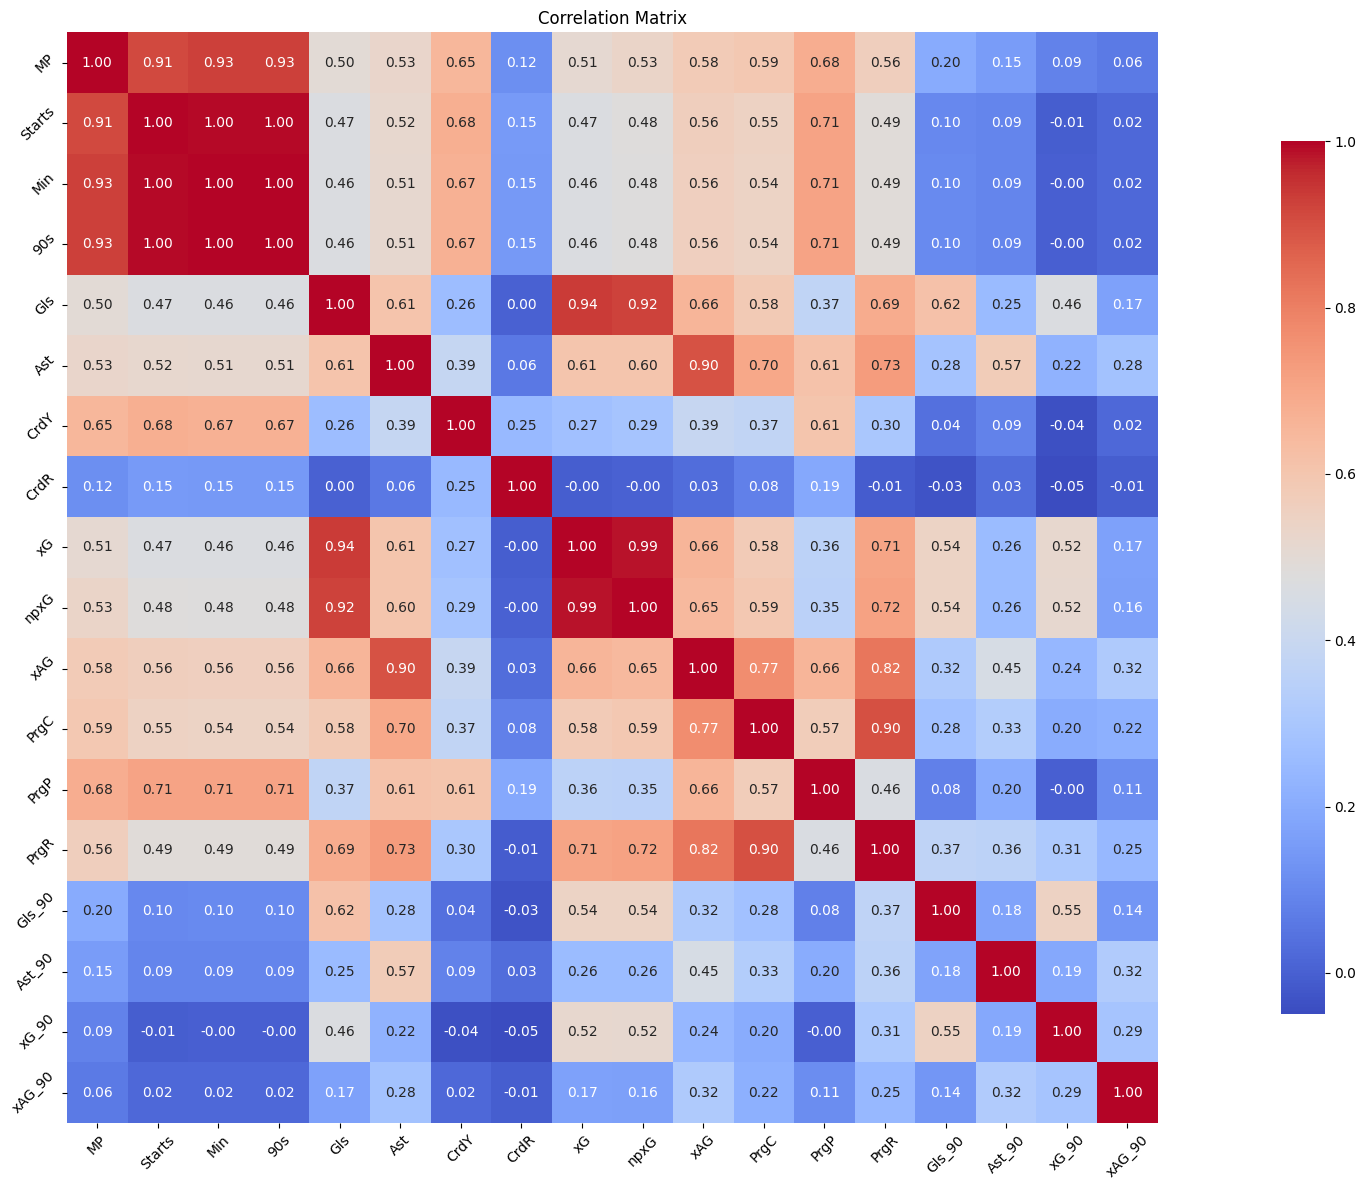

In [72]:
attributes = ["MP","Starts","Min","90s","Gls","Ast","CrdY","CrdR","xG","npxG","xAG","PrgC","PrgP","PrgR","Gls_90","Ast_90","xG_90","xAG_90"]

correlation_matrix = df_1[attributes].corr()


plt.figure(figsize=(25, 12))


sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})


plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.tight_layout()
plt.show()

## Aggregating from player_stats to team_stats

In [74]:
attributes = ["MP","Starts","Min","90s","Gls","Ast","G+A","G-PK","PK","PKatt","CrdY","CrdR","xG","npxG","xAG","npxG+xAG","PrgC","PrgP","PrgR","Gls_90","Ast_90","G+A_90","G-PK_90","G+A-PK_90","xG_90","xAG_90","xG+xAG_90","npxG_90","npxG+xAG_90","Team"]

aggregation_function = {
    'MP': 'sum',
    'Starts': 'sum',
    'Min': 'sum',
    '90s': 'sum',
    'Gls': 'sum',
    'Ast': 'sum',
    'G+A': 'sum',
    'G-PK': 'sum',
    'PK': 'sum',
    'PKatt': 'sum',
    'CrdY': 'sum',
    'CrdR': 'sum',
    'xG': 'mean',
    'npxG': 'mean',
    'xAG': 'mean',
    'npxG+xAG': 'mean',
    'PrgC': 'sum',
    'PrgP': 'sum',
    'PrgR': 'sum',
    'Gls_90': 'mean',
    'Ast_90': 'mean',
    'G+A_90': 'mean',
    'G-PK_90': 'mean',
    'G+A-PK_90': 'mean',
    'xG_90': 'mean',
    'xAG_90': 'mean',
    'xG+xAG_90': 'mean',
    'npxG_90': 'mean',
    'npxG+xAG_90': 'mean'
}
team_stats = df_1.groupby('Team').agg(aggregation_function).reset_index()

df_t = team_stats.copy()

print('Number of rows: ', df_t.shape[0])
print('Number of columns: ', df_t.shape[1])

Number of rows:  20
Number of columns:  30


## Create Mid Table Dataset

### Home and Away Stats of Teams

In [75]:
home_percentage = 0.6
away_percentage = 0.4

df_home_away = df_t.copy()

df_home_away['Home_Gls'] = df_home_away['Gls'] * home_percentage
df_home_away['Away_Gls'] = df_home_away['Gls'] * away_percentage
df_home_away['Home_Ast'] = df_home_away['Ast'] * home_percentage
df_home_away['Away_Ast'] = df_home_away['Ast'] * away_percentage
df_home_away['Home_xG'] = df_home_away['xG'] * home_percentage
df_home_away['Away_xG'] = df_home_away['xG'] * away_percentage
df_home_away['Home_xAG'] = df_home_away['xAG'] * home_percentage
df_home_away['Away_xAG'] = df_home_away['xAG'] * away_percentage
df_home_away['Home_Gls_90'] = df_home_away['Gls_90'] * home_percentage
df_home_away['Away_Gls_90'] = df_home_away['Gls_90'] * away_percentage
df_home_away['Home_Ast_90'] = df_home_away['Ast_90'] * home_percentage
df_home_away['Away_Ast_90'] = df_home_away['Ast_90'] * away_percentage
df_home_away['Home_xG_90'] = df_home_away['xG_90'] * home_percentage
df_home_away['Away_xG_90'] = df_home_away['xG_90'] * away_percentage
df_home_away['Home_xAG_90'] = df_home_away['xAG_90'] * home_percentage
df_home_away['Away_xAG_90'] = df_home_away['xAG_90'] * away_percentage


In [76]:
# df_home_away.to_csv("C:\\Users\\User\\Desktop\\Team_Stats.csv")
df_h_a = df_home_away.copy()
df_2 = df_match.copy()

### Adding new coulmns to the matches dataset

In [77]:
new_columns = [
    'Home_Gls', 'Home_Ast',
    'Home_xG', 'Home_xAG',
    'Home_Gls_90', 'Home_Ast_90',
    'Home_xG_90', 'Home_xAG_90',
    'Away_Gls', 'Away_Ast',
    'Away_xG', 'Away_xAG',
    'Away_Gls_90', 'Away_Ast_90',
    'Away_xG_90', 'Away_xAG_90'
]

for column in new_columns:
    df_2[column] = None

for column in new_columns:
    df_2[column] = pd.to_numeric(df_2[column], errors='coerce')


### Normalizing the Team names in both the datasets and also the vanue values in matches datatset

In [78]:
df_3 = df_h_a.copy()
df_4 = df_2.copy()

In [79]:
df_3['Team_norm'] = df_3['Team'].str.replace(' ', '', regex=False)
team_stats_mapping = df_3.set_index('Team_norm').to_dict(orient='index')

df_4['Team_norm'] = df_4['Team'].str.replace(' ', '', regex=False)
df_4['Opponent_norm'] = df_4['Opponent'].str.replace(' ', '', regex=False)

print("Team Stats Mapping Dictionary:")
print(team_stats_mapping)

Team Stats Mapping Dictionary:
{'Arsenal': {'Team': 'Arsenal', 'MP': 572, 'Starts': 418, 'Min': 37588.0, '90s': 417.5, 'Gls': 86.0, 'Ast': 62.0, 'G+A': 148.0, 'G-PK': 76.0, 'PK': 10.0, 'PKatt': 10.0, 'CrdY': 64.0, 'CrdR': 2.0, 'xG': 3.1239999999999997, 'npxG': 2.812, 'xAG': 2.2359999999999998, 'npxG+xAG': 5.048, 'PrgC': 821.0, 'PrgP': 2106.0, 'PrgR': 2088.0, 'Gls_90': 0.1536, 'Ast_90': 0.1364, 'G+A_90': 0.29, 'G-PK_90': 0.1308, 'G+A-PK_90': 0.2676, 'xG_90': 0.17679999999999998, 'xAG_90': 0.1228, 'xG+xAG_90': 0.29960000000000003, 'npxG_90': 0.158, 'npxG+xAG_90': 0.2812, 'Home_Gls': 51.6, 'Away_Gls': 34.4, 'Home_Ast': 37.199999999999996, 'Away_Ast': 24.8, 'Home_xG': 1.8743999999999996, 'Away_xG': 1.2496, 'Home_xAG': 1.3416, 'Away_xAG': 0.8944, 'Home_Gls_90': 0.09215999999999999, 'Away_Gls_90': 0.061439999999999995, 'Home_Ast_90': 0.08184, 'Away_Ast_90': 0.05456, 'Home_xG_90': 0.10608, 'Away_xG_90': 0.07071999999999999, 'Home_xAG_90': 0.07368, 'Away_xAG_90': 0.049120000000000004}, 'AstonV

In [80]:
def check_team_names(df_3, df_4):

    teams_in_df3 = set(df_3['Team_norm'])
    teams_in_df4 = set(df_4['Team_norm']).union(set(df_4['Opponent_norm']))

    missing_in_df4 = teams_in_df3 - teams_in_df4
    extra_in_df4 = teams_in_df4 - teams_in_df3

    if not missing_in_df4:
        print("All team names from df_3 are present in df_4.")
    else:
        print("Missing team names in df_4:", missing_in_df4)

    if not extra_in_df4:
        print("No extra team names found in df_4.")
    else:
        print("Extra team names found in df_4:", extra_in_df4)

check_team_names(df_3, df_4)

Missing team names in df_4: {'Wolverhampton'}
Extra team names found in df_4: {'SheffieldUtd', 'NewcastleUtd', 'ManchesterUtd', "Nott'hamForest", 'WestHam', 'BrightonandHoveAlbion', 'WolverhamptonWanderers', 'Wolves', 'Tottenham'}


In [81]:
team_stats_mapping = df_3.set_index('Team_norm').to_dict(orient='index')
teams_in_df3 = set(team_stats_mapping.keys())
teams_in_df4 = set(df_4['Team_norm']).union(set(df_4['Opponent_norm']))

missing_in_mapping = teams_in_df4 - teams_in_df3
extra_in_mapping = teams_in_df3 - teams_in_df4

if not missing_in_mapping:
    print("All teams in df_4 have corresponding entries in the mapping dictionary.")
else:
    print("Missing teams in mapping dictionary:", missing_in_mapping)

if not extra_in_mapping:
    print("No extra teams in the mapping dictionary.")
else:
    print("Extra teams in the mapping dictionary:", extra_in_mapping)

Missing teams in mapping dictionary: {'SheffieldUtd', 'NewcastleUtd', 'ManchesterUtd', "Nott'hamForest", 'WestHam', 'BrightonandHoveAlbion', 'WolverhamptonWanderers', 'Wolves', 'Tottenham'}
Extra teams in the mapping dictionary: {'Wolverhampton'}


In [82]:
def verify_data_and_mapping(df_3, df_4, team_stats_mapping):
    teams_in_df3 = set(df_3['Team_norm'])
    teams_in_df4 = set(df_4['Team_norm']).union(set(df_4['Opponent_norm']))

    missing_in_df4 = teams_in_df3 - teams_in_df4
    extra_in_df4 = teams_in_df4 - teams_in_df3

    print("Verification Results:")
    if not missing_in_df4:
        print("All team names from df_3 are present in df_4.")
    else:
        print("Missing team names in df_4:", missing_in_df4)

    if not extra_in_df4:
        print("No extra team names found in df_4.")
    else:
        print("Extra team names found in df_4:", extra_in_df4)

    sample_key = next(iter(team_stats_mapping.keys()), None)
    if sample_key and isinstance(team_stats_mapping[sample_key], dict):
        print("team_stats_mapping is structured correctly.")
    else:
        print("team_stats_mapping has incorrect structure.")

    return missing_in_df4, extra_in_df4

In [83]:
def prepare_match_data(df_4, target_columns, valid_venues=['home', 'away']):
    if 'Venue' not in df_4.columns:
        raise ValueError("Venue column is missing in df_4.")

    invalid_venues = df_4[~df_4['Venue'].isin(valid_venues)]['Venue'].unique()
    if len(invalid_venues) > 0:
        print(f"Invalid venue values found: {invalid_venues}. Please correct them.")
    else:
        print("Venue column contains only valid values.")

    for column in target_columns:
        if column not in df_4.columns:
            df_4[column] = np.nan
            print(f"Created missing column: {column}")
        else:
            print(f"Column already exists: {column}")

    return df_4

In [84]:
target_columns = [
    'Home_Gls', 'Home_Ast', 'Home_xG', 'Home_xAG',
    'Home_Gls_90', 'Home_Ast_90', 'Home_xG_90', 'Home_xAG_90',
    'Away_Gls', 'Away_Ast', 'Away_xG', 'Away_xAG',
    'Away_Gls_90', 'Away_Ast_90', 'Away_xG_90', 'Away_xAG_90'
]

missing_in_df4, extra_in_df4 = verify_data_and_mapping(df_3, df_4, team_stats_mapping)
df_4_prepared = prepare_match_data(df_4, target_columns)

Verification Results:
Missing team names in df_4: {'Wolverhampton'}
Extra team names found in df_4: {'SheffieldUtd', 'NewcastleUtd', 'ManchesterUtd', "Nott'hamForest", 'WestHam', 'BrightonandHoveAlbion', 'WolverhamptonWanderers', 'Wolves', 'Tottenham'}
team_stats_mapping is structured correctly.
Invalid venue values found: ['Away' 'Home']. Please correct them.
Column already exists: Home_Gls
Column already exists: Home_Ast
Column already exists: Home_xG
Column already exists: Home_xAG
Column already exists: Home_Gls_90
Column already exists: Home_Ast_90
Column already exists: Home_xG_90
Column already exists: Home_xAG_90
Column already exists: Away_Gls
Column already exists: Away_Ast
Column already exists: Away_xG
Column already exists: Away_xAG
Column already exists: Away_Gls_90
Column already exists: Away_Ast_90
Column already exists: Away_xG_90
Column already exists: Away_xAG_90


In [85]:
def correct_venue_values(df, column_name='Venue', valid_values=['home', 'away']):

    df[column_name] = df[column_name].str.strip().str.lower()

    invalid_values = df[~df[column_name].isin(valid_values)][column_name].unique()

    if len(invalid_values) > 0:
        print(f"Invalid values still present in '{column_name}': {invalid_values}.")
    else:
        print(f"All values in '{column_name}' are valid.")

    return df

df_4 = correct_venue_values(df_4)

All values in 'Venue' are valid.


### Filling the empty columns in matches dataset

In [86]:
def standardize_team_names(df, column_name):

    df[column_name] = df[column_name].str.replace(' ', '', regex=False)

    special_cases = {
        'WolverhamptonWanderers': 'Wolverhampton',
        'BrightonandHoveAlbion': 'Brighton',
        'SheffieldUtd': 'SheffieldUnited',
        'WestHam': 'WestHamUnited',
        "Nott'hamForest": 'NottinghamForest',
        'Wolves': 'Wolverhampton',
        'Tottenham': 'TottenhamHotspur',
        'NewcastleUtd': 'NewcastleUnited',
        'ManchesterUtd': 'ManchesterUnited'
    }
    for key, value in special_cases.items():
        df.loc[df[column_name] == key, column_name] = value

    return df

df_4 = standardize_team_names(df_4, 'Team_norm')
df_4 = standardize_team_names(df_4, 'Opponent_norm')
df_3 = standardize_team_names(df_3, 'Team_norm')

missing_in_df_3 = set(df_4['Team_norm']).union(set(df_4['Opponent_norm'])) - set(df_3['Team_norm'])
if missing_in_df_3:
    print(f"Missing teams in df_3: {missing_in_df_3}")
else:
    print("All team names in df_4 are present in df_3.")

columns_to_check = ['Home_Gls', 'Home_Ast', 'Home_xG', 'Home_xAG', 'Home_Gls_90', 'Home_Ast_90',
                    'Home_xG_90', 'Home_xAG_90', 'Away_Gls', 'Away_Ast', 'Away_xG', 'Away_xAG',
                    'Away_Gls_90', 'Away_Ast_90', 'Away_xG_90', 'Away_xAG_90']
for column in columns_to_check:
    df_4[column] = pd.to_numeric(df_4[column], errors='coerce')

for index, row in df_4.iterrows():
    if row['Venue'] == 'home':
        if pd.isna(row['Home_Gls']):
            team_stats = df_3.loc[df_3['Team_norm'] == row['Team_norm']].squeeze()
            if not team_stats.empty:
                df_4.at[index, 'Home_Gls'] = team_stats['Home_Gls']
                df_4.at[index, 'Home_Ast'] = team_stats['Home_Ast']
                df_4.at[index, 'Home_xG'] = team_stats['Home_xG']
                df_4.at[index, 'Home_xAG'] = team_stats['Home_xAG']
                df_4.at[index, 'Home_Gls_90'] = team_stats['Home_Gls_90']
                df_4.at[index, 'Home_Ast_90'] = team_stats['Home_Ast_90']
                df_4.at[index, 'Home_xG_90'] = team_stats['Home_xG_90']
                df_4.at[index, 'Home_xAG_90'] = team_stats['Home_xAG_90']

        if pd.isna(row['Away_Gls']):
            opponent_stats = df_3.loc[df_3['Team_norm'] == row['Opponent_norm']].squeeze()
            if not opponent_stats.empty:
                df_4.at[index, 'Away_Gls'] = opponent_stats['Away_Gls']
                df_4.at[index, 'Away_Ast'] = opponent_stats['Away_Ast']
                df_4.at[index, 'Away_xG'] = opponent_stats['Away_xG']
                df_4.at[index, 'Away_xAG'] = opponent_stats['Away_xAG']
                df_4.at[index, 'Away_Gls_90'] = opponent_stats['Away_Gls_90']
                df_4.at[index, 'Away_Ast_90'] = opponent_stats['Away_Ast_90']
                df_4.at[index, 'Away_xG_90'] = opponent_stats['Away_xG_90']
                df_4.at[index, 'Away_xAG_90'] = opponent_stats['Away_xAG_90']

    elif row['Venue'] == 'away':
        if pd.isna(row['Away_Gls']):
            team_stats = df_3.loc[df_3['Team_norm'] == row['Team_norm']].squeeze()
            if not team_stats.empty:
                df_4.at[index, 'Away_Gls'] = team_stats['Away_Gls']
                df_4.at[index, 'Away_Ast'] = team_stats['Away_Ast']
                df_4.at[index, 'Away_xG'] = team_stats['Away_xG']
                df_4.at[index, 'Away_xAG'] = team_stats['Away_xAG']
                df_4.at[index, 'Away_Gls_90'] = team_stats['Away_Gls_90']
                df_4.at[index, 'Away_Ast_90'] = team_stats['Away_Ast_90']
                df_4.at[index, 'Away_xG_90'] = team_stats['Away_xG_90']
                df_4.at[index, 'Away_xAG_90'] = team_stats['Away_xAG_90']

        if pd.isna(row['Home_Gls']):
            opponent_stats = df_3.loc[df_3['Team_norm'] == row['Opponent_norm']].squeeze()
            if not opponent_stats.empty:
                df_4.at[index, 'Home_Gls'] = opponent_stats['Home_Gls']
                df_4.at[index, 'Home_Ast'] = opponent_stats['Home_Ast']
                df_4.at[index, 'Home_xG'] = opponent_stats['Home_xG']
                df_4.at[index, 'Home_xAG'] = opponent_stats['Home_xAG']
                df_4.at[index, 'Home_Gls_90'] = opponent_stats['Home_Gls_90']
                df_4.at[index, 'Home_Ast_90'] = opponent_stats['Home_Ast_90']
                df_4.at[index, 'Home_xG_90'] = opponent_stats['Home_xG_90']
                df_4.at[index, 'Home_xAG_90'] = opponent_stats['Home_xAG_90']

print("\nRemaining missing values in df_4:")
print(df_4.isna().sum())



All team names in df_4 are present in df_3.

Remaining missing values in df_4:
Unnamed: 0         0
Date               0
Time               0
Comp               0
Round              0
Day                0
Venue              0
Result             0
GF                 0
GA                 0
Opponent           0
xG                 0
xGA                0
Poss               0
Attendance         0
Captain            0
Formation          0
Referee            0
Match Report       0
Notes            760
Sh                 0
SoT                0
Dist               0
FK                 0
PK                 0
PKatt              0
Season             0
Team               0
Home_Gls           0
Home_Ast           0
Home_xG            0
Home_xAG           0
Home_Gls_90        0
Home_Ast_90        0
Home_xG_90         0
Home_xAG_90        0
Away_Gls           0
Away_Ast           0
Away_xG            0
Away_xAG           0
Away_Gls_90        0
Away_Ast_90        0
Away_xG_90         0
Away_xAG_90       

## Feature Engineering

In [87]:
df_mid_table = df_4.copy()

df_mid_table['Goal_Difference'] = df_mid_table['GF'] - df_mid_table['GA']
df_mid_table['Total Goals'] = df_mid_table['GF'] + df_mid_table['GA']

# print(df_mid_table[['GF', 'GA', 'Goal_Difference', 'Total Goals']].head())

### columns dropped in mid table

In [88]:
columns_to_drop = [
    'Unnamed: 0',
    'Notes',
    'Comp',
    'Attendance',
    'Captain',
    'Formation',
    'Referee',
    'Match Report',
    'Date',
    'Time',
    'Round',
    'Day',
    'GF',
    'GA',
    'Season',
    'Goal_Difference'
]

df_mid_table.drop(columns=columns_to_drop, inplace=True)

print("Remaining columns in df_mid_table:")
print(df_mid_table.columns)


Remaining columns in df_mid_table:
Index(['Venue', 'Result', 'Opponent', 'xG', 'xGA', 'Poss', 'Sh', 'SoT', 'Dist',
       'FK', 'PK', 'PKatt', 'Team', 'Home_Gls', 'Home_Ast', 'Home_xG',
       'Home_xAG', 'Home_Gls_90', 'Home_Ast_90', 'Home_xG_90', 'Home_xAG_90',
       'Away_Gls', 'Away_Ast', 'Away_xG', 'Away_xAG', 'Away_Gls_90',
       'Away_Ast_90', 'Away_xG_90', 'Away_xAG_90', 'Team_norm',
       'Opponent_norm', 'Total Goals'],
      dtype='object')


In [89]:
df_mid_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Venue          760 non-null    object 
 1   Result         760 non-null    object 
 2   Opponent       760 non-null    object 
 3   xG             760 non-null    float64
 4   xGA            760 non-null    float64
 5   Poss           760 non-null    float64
 6   Sh             760 non-null    float64
 7   SoT            760 non-null    float64
 8   Dist           760 non-null    float64
 9   FK             760 non-null    float64
 10  PK             760 non-null    int64  
 11  PKatt          760 non-null    int64  
 12  Team           760 non-null    object 
 13  Home_Gls       760 non-null    float64
 14  Home_Ast       760 non-null    float64
 15  Home_xG        760 non-null    float64
 16  Home_xAG       760 non-null    float64
 17  Home_Gls_90    760 non-null    float64
 18  Home_Ast_9

## Output Column

In [90]:
columns = [col for col in df_mid_table.columns if col != 'Result']

columns.append('Result')

df_mid_table = df_mid_table[columns]

df_mid_table['Result'] = df_mid_table['Result'].map({'W': 3, 'D': 1, 'L': 0})

print("\nUpdated DataFrame:")
print(df_mid_table)


Updated DataFrame:
    Venue         Opponent   xG  xGA  Poss    Sh   SoT  Dist   FK  PK  ...  \
0    away          Burnley  1.9  0.3  65.0  17.0   8.0  13.9  0.0   0  ...   
1    home    Newcastle Utd  1.0  0.3  59.0  14.0   4.0  17.9  0.0   0  ...   
2    away    Sheffield Utd  3.5  0.7  79.0  29.0   9.0  17.3  2.0   0  ...   
3    home           Fulham  2.2  1.4  68.0   6.0   4.0  14.8  0.0   1  ...   
4    away         West Ham  3.6  0.9  68.0  29.0  13.0  16.4  1.0   0  ...   
..    ...              ...  ...  ...   ...   ...   ...   ...  ...  ..  ...   
755  away   Manchester Utd  0.8  2.9  29.0  10.0   4.0  17.8  1.0   0  ...   
756  away    Newcastle Utd  1.5  3.1  40.0  15.0   4.0  13.5  0.0   0  ...   
757  home  Nott'ham Forest  2.2  1.5  54.0  16.0   4.0  18.0  0.0   1  ...   
758  away          Everton  0.6  2.3  42.0  13.0   1.0  21.0  0.0   0  ...   
759  home        Tottenham  1.0  3.1  25.0   6.0   1.0  18.0  1.0   0  ...   

      Away_xG  Away_xAG  Away_Gls_90  Away_

# Task 2: Dataset Splitting

In [131]:

def train_test_split(df, stratify=12, random_state=12):

    train_data = []
    test_data = []

    grouped = df.groupby('Team_norm')

    for team, group in grouped:
        group = group.sample(frac=1, random_state=random_state).reset_index(drop=True)

        test_matches = group.sample(n=stratify, random_state=random_state)
        test_data.append(test_matches)

        train_matches = group.drop(test_matches.index)
        train_data.append(train_matches)

    train_df = pd.concat(train_data, ignore_index=True)
    test_df = pd.concat(test_data, ignore_index=True)

    X_train = train_df.drop(columns=['Result'])
    y_train = train_df['Result']

    X_test = test_df.drop(columns=['Result'])
    y_test = test_df['Result']

    numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    return X_train_scaled, y_train, X_test_scaled, y_test


X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

team_frequency = X_test['Team_norm'].value_counts()


print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

print("\nFrequency of Teams in X_test:")
print(team_frequency)


Training set size: 520
Testing set size: 240

Frequency of Teams in X_test:
Team_norm
Arsenal             12
AstonVilla          12
WestHamUnited       12
TottenhamHotspur    12
SheffieldUnited     12
NottinghamForest    12
NewcastleUnited     12
ManchesterUnited    12
ManchesterCity      12
LutonTown           12
Liverpool           12
Fulham              12
Everton             12
CrystalPalace       12
Chelsea             12
Burnley             12
Brighton            12
Brentford           12
Bournemouth         12
Wolverhampton       12
Name: count, dtype: int64


# Task 3 & 4: Model Training

## With Default Hyperparameter

### K-NN

In [92]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

knn.fit(X_train_numeric, y_train)

y_train_pred = knn.predict(X_train_numeric)
y_test_pred = knn.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("KNN Training Accuracy:", train_accuracy)
print("KNN Testing Accuracy:", test_accuracy)

KNN Training Accuracy: 0.7019230769230769
KNN Testing Accuracy: 0.5541666666666667


### DT

In [93]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

dt = DecisionTreeClassifier()

dt.fit(X_train_numeric, y_train)

y_train_pred = dt.predict(X_train_numeric)
y_test_pred = dt.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("DT Training Accuracy:", train_accuracy)
print("DT Testing Accuracy:", test_accuracy)

DT Training Accuracy: 1.0
DT Testing Accuracy: 0.5208333333333334


### RF

In [94]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

rf = RandomForestClassifier()

rf.fit(X_train_numeric, y_train)

y_train_pred = rf.predict(X_train_numeric)
y_test_pred = rf.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print("RF Training Accuracy:", train_accuracy)
print("RF Testing Accuracy:", test_accuracy)

RF Training Accuracy: 1.0
RF Testing Accuracy: 0.575


### SVM

In [95]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

svm = SVC()

svm.fit(X_train_numeric, y_train)

y_train_pred = svm.predict(X_train_numeric)
y_test_pred = svm.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print("SVM Training Accuracy:", train_accuracy)
print("SVM Testing Accuracy:", test_accuracy)

SVM Training Accuracy: 0.7846153846153846
SVM Testing Accuracy: 0.6083333333333333


### AB

In [96]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

ab = AdaBoostClassifier(n_estimators=50)

ab.fit(X_train_numeric, y_train)

y_train_pred = ab.predict(X_train_numeric)
y_test_pred = ab.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


print("AB Training Accuracy:", train_accuracy)
print("AB Testing Accuracy:", test_accuracy)

AB Training Accuracy: 0.7730769230769231
AB Testing Accuracy: 0.575


### XGB

In [97]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

y_train_mapped = y_train.map({0:0, 1:1, 3:2})
y_test_mapped = y_test.map({0:0, 1:1, 3:2})

xgb.fit(X_train_numeric, y_train_mapped)

y_train_pred = xgb.predict(X_train_numeric)
y_test_pred = xgb.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train_mapped, y_train_pred)
test_accuracy = accuracy_score(y_test_mapped, y_test_pred)


print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.6125


## With Optimized Hyperparameter

### K-NN

In [99]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35],
    'leaf_size': [5,10,15],
    'algorithm': [ 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

grid_search = GridSearchCV(knn, param_grid, cv=5)

grid_search.fit(X_train_numeric, y_train)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = best_knn.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("KNN Training Accuracy:", train_accuracy)
print("KNN Testing Accuracy:", test_accuracy)

Best hyperparameters: {'algorithm': 'ball_tree', 'leaf_size': 5, 'n_neighbors': 33, 'p': 2}
KNN Training Accuracy: 0.6442307692307693
KNN Testing Accuracy: 0.6


### DT

In [100]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

dt = DecisionTreeClassifier()

param_grid = {
    'criterion': ['gini','entropy'],
    'splitter': ['best'],
    'min_samples_split':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    'min_samples_leaf': [1,2,3,4,5]
}

grid_search = GridSearchCV(dt, param_grid, cv=5)

grid_search.fit(X_train_numeric, y_train)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_dt = grid_search.best_estimator_

y_train_pred = best_dt.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = best_dt.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("DT Training Accuracy:", train_accuracy)
print("DT Testing Accuracy:", test_accuracy)

Best hyperparameters: {'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 0.1, 'splitter': 'best'}
DT Training Accuracy: 0.7269230769230769
DT Testing Accuracy: 0.55


### RF

In [101]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini','entropy']
}

grid_search = GridSearchCV(rf, param_grid, cv=5)

grid_search.fit(X_train_numeric, y_train)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_rf = grid_search.best_estimator_

y_train_pred = best_rf.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = best_rf.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("RF Training Accuracy:", train_accuracy)
print("RF Testing Accuracy:", test_accuracy)

Best hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RF Training Accuracy: 0.9865384615384616
RF Testing Accuracy: 0.5875


### SVM

In [102]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

svm = SVC()

param_grid = {
    'C': [0.1, 1.0, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(svm, param_grid, cv=5)

grid_search.fit(X_train_numeric, y_train)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_svm = grid_search.best_estimator_

y_train_pred = best_svm.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = best_svm.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("SVM Training Accuracy:", train_accuracy)
print("SVM Testing Accuracy:", test_accuracy)

Best hyperparameters: {'C': 0.1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
SVM Training Accuracy: 0.6788461538461539
SVM Testing Accuracy: 0.6208333333333333


### AB

In [103]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

ab = AdaBoostClassifier()

param_grid = {
    'n_estimators': [10,50,100,200],
    'learning_rate':[0.1,0.5,1.0],
    # 'algorithm': ['SAMME','SAMME.R']
    'algorithm': ['SAMME']
}

grid_search = GridSearchCV(ab, param_grid, cv=5)

grid_search.fit(X_train_numeric, y_train)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_ab = grid_search.best_estimator_

y_train_pred = best_ab.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = best_ab.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("AB Training Accuracy:", train_accuracy)
print("AB Testing Accuracy:", test_accuracy)


Best hyperparameters: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}
AB Training Accuracy: 0.7134615384615385
AB Testing Accuracy: 0.5708333333333333


### XGB

In [104]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

xgb = XGBClassifier( eval_metric='mlogloss')

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb, param_grid, cv=5)

y_train_mapped = y_train.map({0:0, 1:1, 3:2})
y_test_mapped = y_test.map({0:0, 1:1, 3:2})

grid_search.fit(X_train_numeric, y_train_mapped)

best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

best_xgb = grid_search.best_estimator_

y_train_pred = best_xgb.predict(X_train_numeric)
train_accuracy = accuracy_score(y_train_mapped, y_train_pred)

y_test_pred = best_xgb.predict(X_test_numeric)
test_accuracy = accuracy_score(y_test_mapped, y_test_pred)

print("XGB Training Accuracy:", train_accuracy)
print("XGB Testing Accuracy:", test_accuracy)

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
XGB Training Accuracy: 1.0
XGB Testing Accuracy: 0.6041666666666666


## Stacking

### with default hyperparameter

In [132]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('svm', SVC()),
    ('ada', AdaBoostClassifier(algorithm='SAMME')),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stacking_clf.fit(X_train_numeric, y_train)

y_pred = stacking_clf.predict(X_test_numeric)

accuracy = accuracy_score(y_test, y_pred)
print("Stacking Classifier Accuracy:", accuracy)

Stacking Classifier Accuracy: 0.6166666666666667


### with optimized Hyperparameters

In [133]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

base_models = [
    ('svm', SVC(C=0.1, kernel='linear', gamma='scale', class_weight=None)),
    ('xgb', XGBClassifier(learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stacking_clf.fit(X_train_numeric, y_train)

y_pred = stacking_clf.predict(X_test_numeric)

accuracy = accuracy_score(y_test, y_pred)
print("Stacking Classifier Accuracy:", accuracy)

Stacking Classifier Accuracy: 0.6375


# Task 5: Classification Reports & Confusion Matrix

## K-NN

              precision    recall  f1-score   support

           0       0.58      0.70      0.64        98
           1       0.24      0.19      0.21        48
           3       0.65      0.59      0.62        94

    accuracy                           0.55       240
   macro avg       0.49      0.49      0.49       240
weighted avg       0.54      0.55      0.54       240





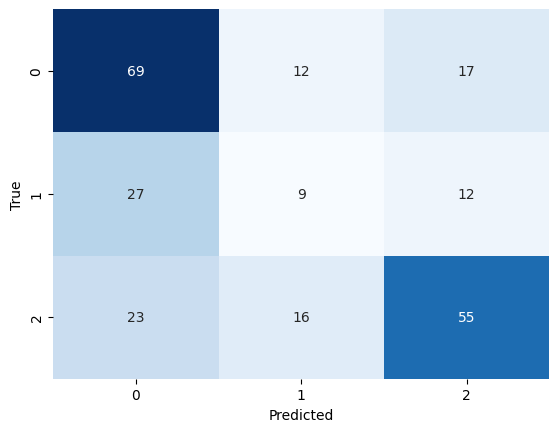

In [106]:
# K-NN

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

knn.fit(X_train_numeric, y_train)

y_train_pred = knn.predict(X_train_numeric)
y_test_pred = knn.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)


# print("KNN Training Accuracy:", train_accuracy)
# print("KNN Testing Accuracy:", test_accuracy)

classification_report_KNN = classification_report(y_test, y_test_pred)
print (classification_report_KNN)
print("\n")

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")

##Decision Tree

              precision    recall  f1-score   support

           0       0.58      0.52      0.55        98
           1       0.37      0.35      0.36        48
           3       0.56      0.63      0.59        94

    accuracy                           0.53       240
   macro avg       0.50      0.50      0.50       240
weighted avg       0.53      0.53      0.53       240





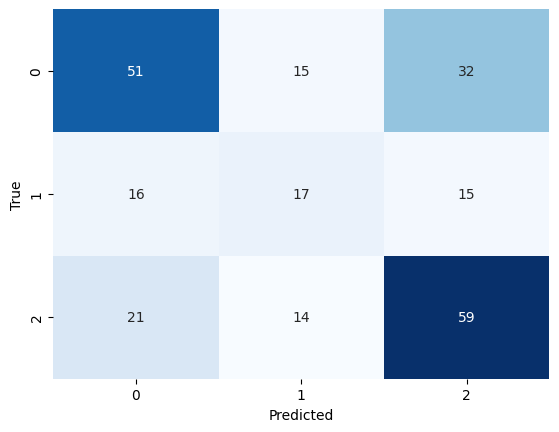

In [107]:
# DT

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

dt = DecisionTreeClassifier()

dt.fit(X_train_numeric, y_train)

y_train_pred = dt.predict(X_train_numeric)
y_test_pred = dt.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# print("DT Training Accuracy:", train_accuracy)
# print("DT Testing Accuracy:", test_accuracy)

classification_report_DT = classification_report(y_test, y_test_pred)
print (classification_report_DT)
print("\n")

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")



##Random Forest

              precision    recall  f1-score   support

           0       0.62      0.66      0.64        98
           1       0.30      0.15      0.20        48
           3       0.59      0.71      0.65        94

    accuracy                           0.58       240
   macro avg       0.51      0.51      0.50       240
weighted avg       0.55      0.58      0.56       240





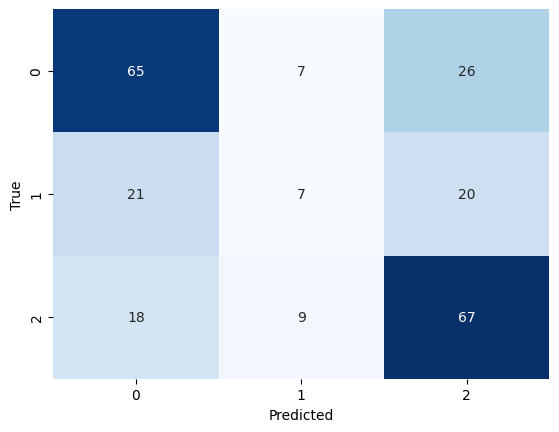

In [108]:
# RF

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

rf = RandomForestClassifier()

rf.fit(X_train_numeric, y_train)

y_train_pred = rf.predict(X_train_numeric)
y_test_pred = rf.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# print("RF Training Accuracy:", train_accuracy)
# print("RF Testing Accuracy:", test_accuracy)

classification_report_RF = classification_report(y_test, y_test_pred)
print (classification_report_RF)
print("\n")

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")

##SVM

              precision    recall  f1-score   support

           0       0.63      0.72      0.67        98
           1       0.33      0.15      0.20        48
           3       0.64      0.72      0.68        94

    accuracy                           0.61       240
   macro avg       0.53      0.53      0.52       240
weighted avg       0.57      0.61      0.58       240





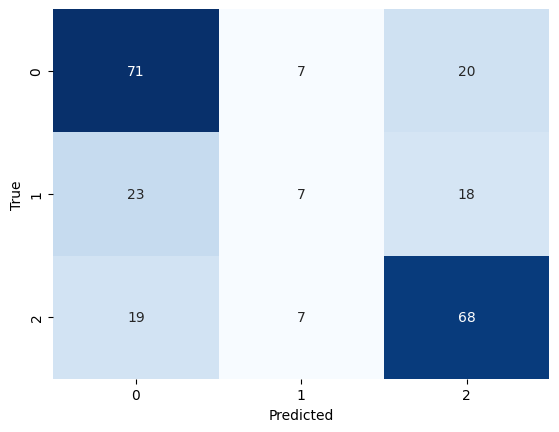

In [109]:
# SVM

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

svm = SVC()

svm.fit(X_train_numeric, y_train)

y_train_pred = svm.predict(X_train_numeric)
y_test_pred = svm.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# print("SVM Training Accuracy:", train_accuracy)
# print("SVM Testing Accuracy:", test_accuracy)

classification_report_SVC = classification_report(y_test, y_test_pred)
print (classification_report_SVC)
print("\n")

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")

##AdaBoost

              precision    recall  f1-score   support

           0       0.61      0.62      0.62        98
           1       0.42      0.29      0.35        48
           3       0.59      0.67      0.63        94

    accuracy                           0.57       240
   macro avg       0.54      0.53      0.53       240
weighted avg       0.56      0.57      0.57       240





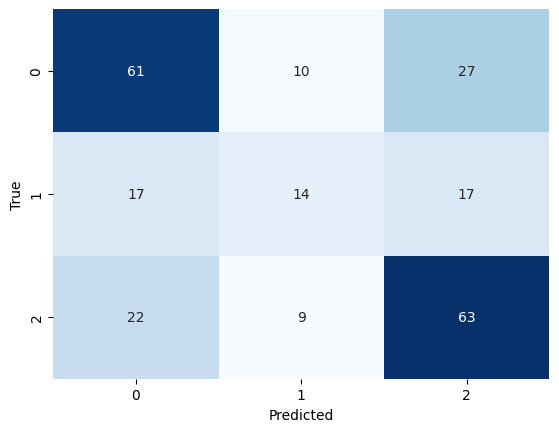

In [110]:
# AB

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

ab = AdaBoostClassifier(n_estimators=50)

ab.fit(X_train_numeric, y_train)

y_train_pred = ab.predict(X_train_numeric)
y_test_pred = ab.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# print("AB Training Accuracy:", train_accuracy)
# print("AB Testing Accuracy:", test_accuracy)

classification_report_AB = classification_report(y_test, y_test_pred)
print (classification_report_AB)
print("\n")

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")

##XGBoost

              precision    recall  f1-score   support

           0       0.64      0.66      0.65        98
           1       0.42      0.29      0.35        48
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00        94

    accuracy                           0.33       240
   macro avg       0.27      0.24      0.25       240
weighted avg       0.35      0.33      0.34       240



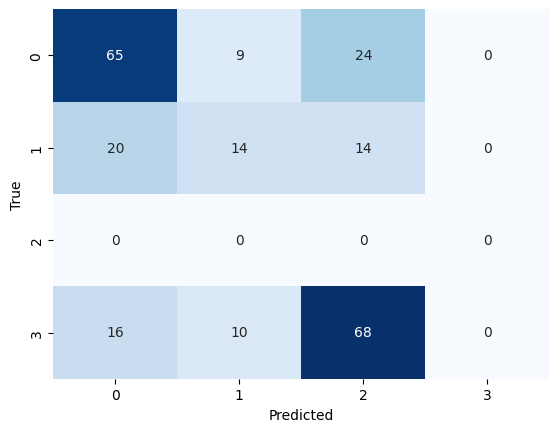

In [111]:
# XGB

X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

y_train_mapped = y_train.map({0:0, 1:1, 3:2})
y_test_mapped = y_test.map({0:0, 1:1, 3:2})

xgb.fit(X_train_numeric, y_train_mapped)

y_train_pred = xgb.predict(X_train_numeric)
y_test_pred = xgb.predict(X_test_numeric)

train_accuracy = accuracy_score(y_train_mapped, y_train_pred)
test_accuracy = accuracy_score(y_test_mapped, y_test_pred)

# print("XGB Training Accuracy:", train_accuracy)
# print("XGB Testing Accuracy:", test_accuracy)

classification_report_XGB = classification_report(y_test, y_test_pred)
print (classification_report_XGB)

#confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf_matrix, annot=True, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("\n")


# Task 7: Applying LIME explainable AI for the best-performed model

In [122]:
X = df_mid_table.drop(columns=['Result'])
y = df_mid_table['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=27, algorithm='ball_tree', leaf_size=5, p=2)),
    ('dt', DecisionTreeClassifier(criterion='gini', min_samples_split=0.7, min_samples_leaf=1, splitter='best')),
    ('rf', RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=5, min_samples_split=5)),
    ('svm', SVC(C=0.1, kernel='linear', gamma='scale', class_weight=None)),
    ('ada', AdaBoostClassifier(learning_rate=0.1, n_estimators=50, algorithm='SAMME')),
    ('xgb', XGBClassifier(learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stacking_clf.fit(X_train_numeric, y_train)

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_numeric.values,
    feature_names=X_train_numeric.columns,
    class_names=np.unique(y_train)
)

instance_idx = 10

instance = X_test_numeric.iloc[instance_idx].values.reshape(1, -1)
predicted_class = stacking_clf.predict(instance)[0]

explanation = explainer.explain_instance(
    data_row=instance[0],  # Changed 'instance' to 'data_row' and used the first row
    predict_fn=stacking_clf.predict_proba,  # Added 'predict_fn' for probabilities
    num_features=5
)
explanation_list = explanation.as_list()

# Print the explanation in a readable format
for feature, weight in explanation_list:
    print(f"{feature}: {weight}")

Home_Gls > 43.20: -0.032767823525373704
Home_xG_90 > 0.10: 0.02032757236606165
3.00 < Total Goals <= 4.00: 0.01795216230068205
Home_Ast_90 > 0.07: -0.017302519696280137
1.40 < xGA <= 2.10: 0.01537376206902334


# Task 8: Applying SMOTE for training samples

In [128]:

# Assuming df_mid_table contains the data
X = df_mid_table.drop(columns=['Result'])  # Replace 'Result' with the actual target column name
y = df_mid_table['Result']  # Replace 'Result' with the actual target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

# Select numeric features
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

# Define base models
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=27, algorithm='ball_tree', leaf_size=5, p=2)),
    ('dt', DecisionTreeClassifier(criterion='gini', min_samples_split=0.7, min_samples_leaf=1, splitter='best')),
    ('rf', RandomForestClassifier(n_estimators=50, criterion='entropy', max_depth=5, min_samples_split=5)),
    ('svm', SVC(C=0.1, kernel='linear', gamma='scale', class_weight=None)),
    ('ada', AdaBoostClassifier(learning_rate=0.1, n_estimators=50, algorithm='SAMME')),
    ('xgb', XGBClassifier(learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8))
]

# Define meta-model
meta_model = LogisticRegression()

# Create stacking classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Train and evaluate on original (unbalanced) data
stacking_clf.fit(X_train_numeric, y_train)
y_pred_original = stacking_clf.predict(X_test_numeric)
accuracy_original = accuracy_score(y_test, y_pred_original)
print("Original Accuracy (without SMOTE):", accuracy_original)

# Apply SMOTE or ADASYN to the training data
oversampler = SMOTE(random_state=12)  # Use ADASYN(random_state=12) for ADASYN
X_train_balanced, y_train_balanced = oversampler.fit_resample(X_train_numeric, y_train)

# Train and evaluate on SMOTE-balanced data
stacking_clf.fit(X_train_balanced, y_train_balanced)
y_pred_smote = stacking_clf.predict(X_test_numeric)
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print("SMOTE Accuracy:", accuracy_smote)

Original Accuracy (without SMOTE): 0.6403508771929824
SMOTE Accuracy: 0.6535087719298246


Original class distribution: Counter({3: 298, 0: 298, 1: 164})
Class distribution after SMOTE: Counter({3: 219, 1: 219, 0: 219})


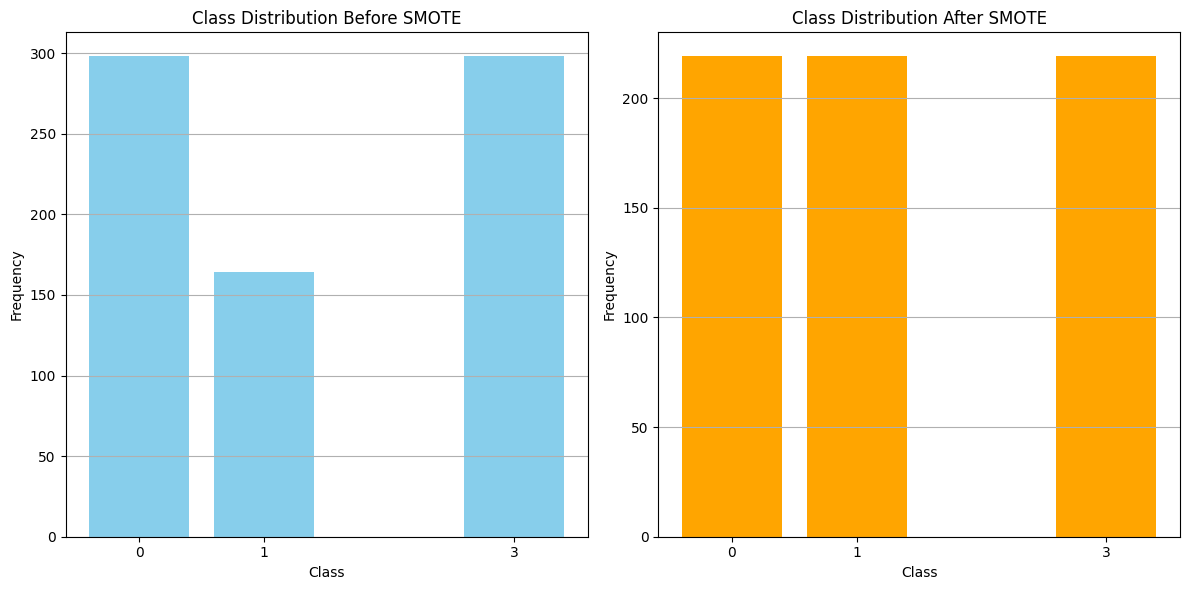

In [127]:
# Assuming df_mid_table contains the data
X = df_mid_table.drop(columns=['Result'])  # Replace 'Result' with the actual target column name
y = df_mid_table['Result']  # Replace 'Result' with the actual target column name

# Display original class distribution
original_distribution = Counter(y)
print("Original class distribution:", original_distribution)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

# Select numeric features
X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

# Apply SMOTE to the training data
oversampler = SMOTE(random_state=12)
X_train_balanced, y_train_balanced = oversampler.fit_resample(X_train_numeric, y_train)

# Display new class distribution
balanced_distribution = Counter(y_train_balanced)
print("Class distribution after SMOTE:", balanced_distribution)

# Plot the class distributions before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for original distribution
axes[0].bar(original_distribution.keys(), original_distribution.values(), color='skyblue')
axes[0].set_title("Class Distribution Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(list(original_distribution.keys()))
axes[0].grid(axis='y')

# Bar chart for SMOTE-applied distribution
axes[1].bar(balanced_distribution.keys(), balanced_distribution.values(), color='orange')
axes[1].set_title("Class Distribution After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(list(balanced_distribution.keys()))
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

# Points Table

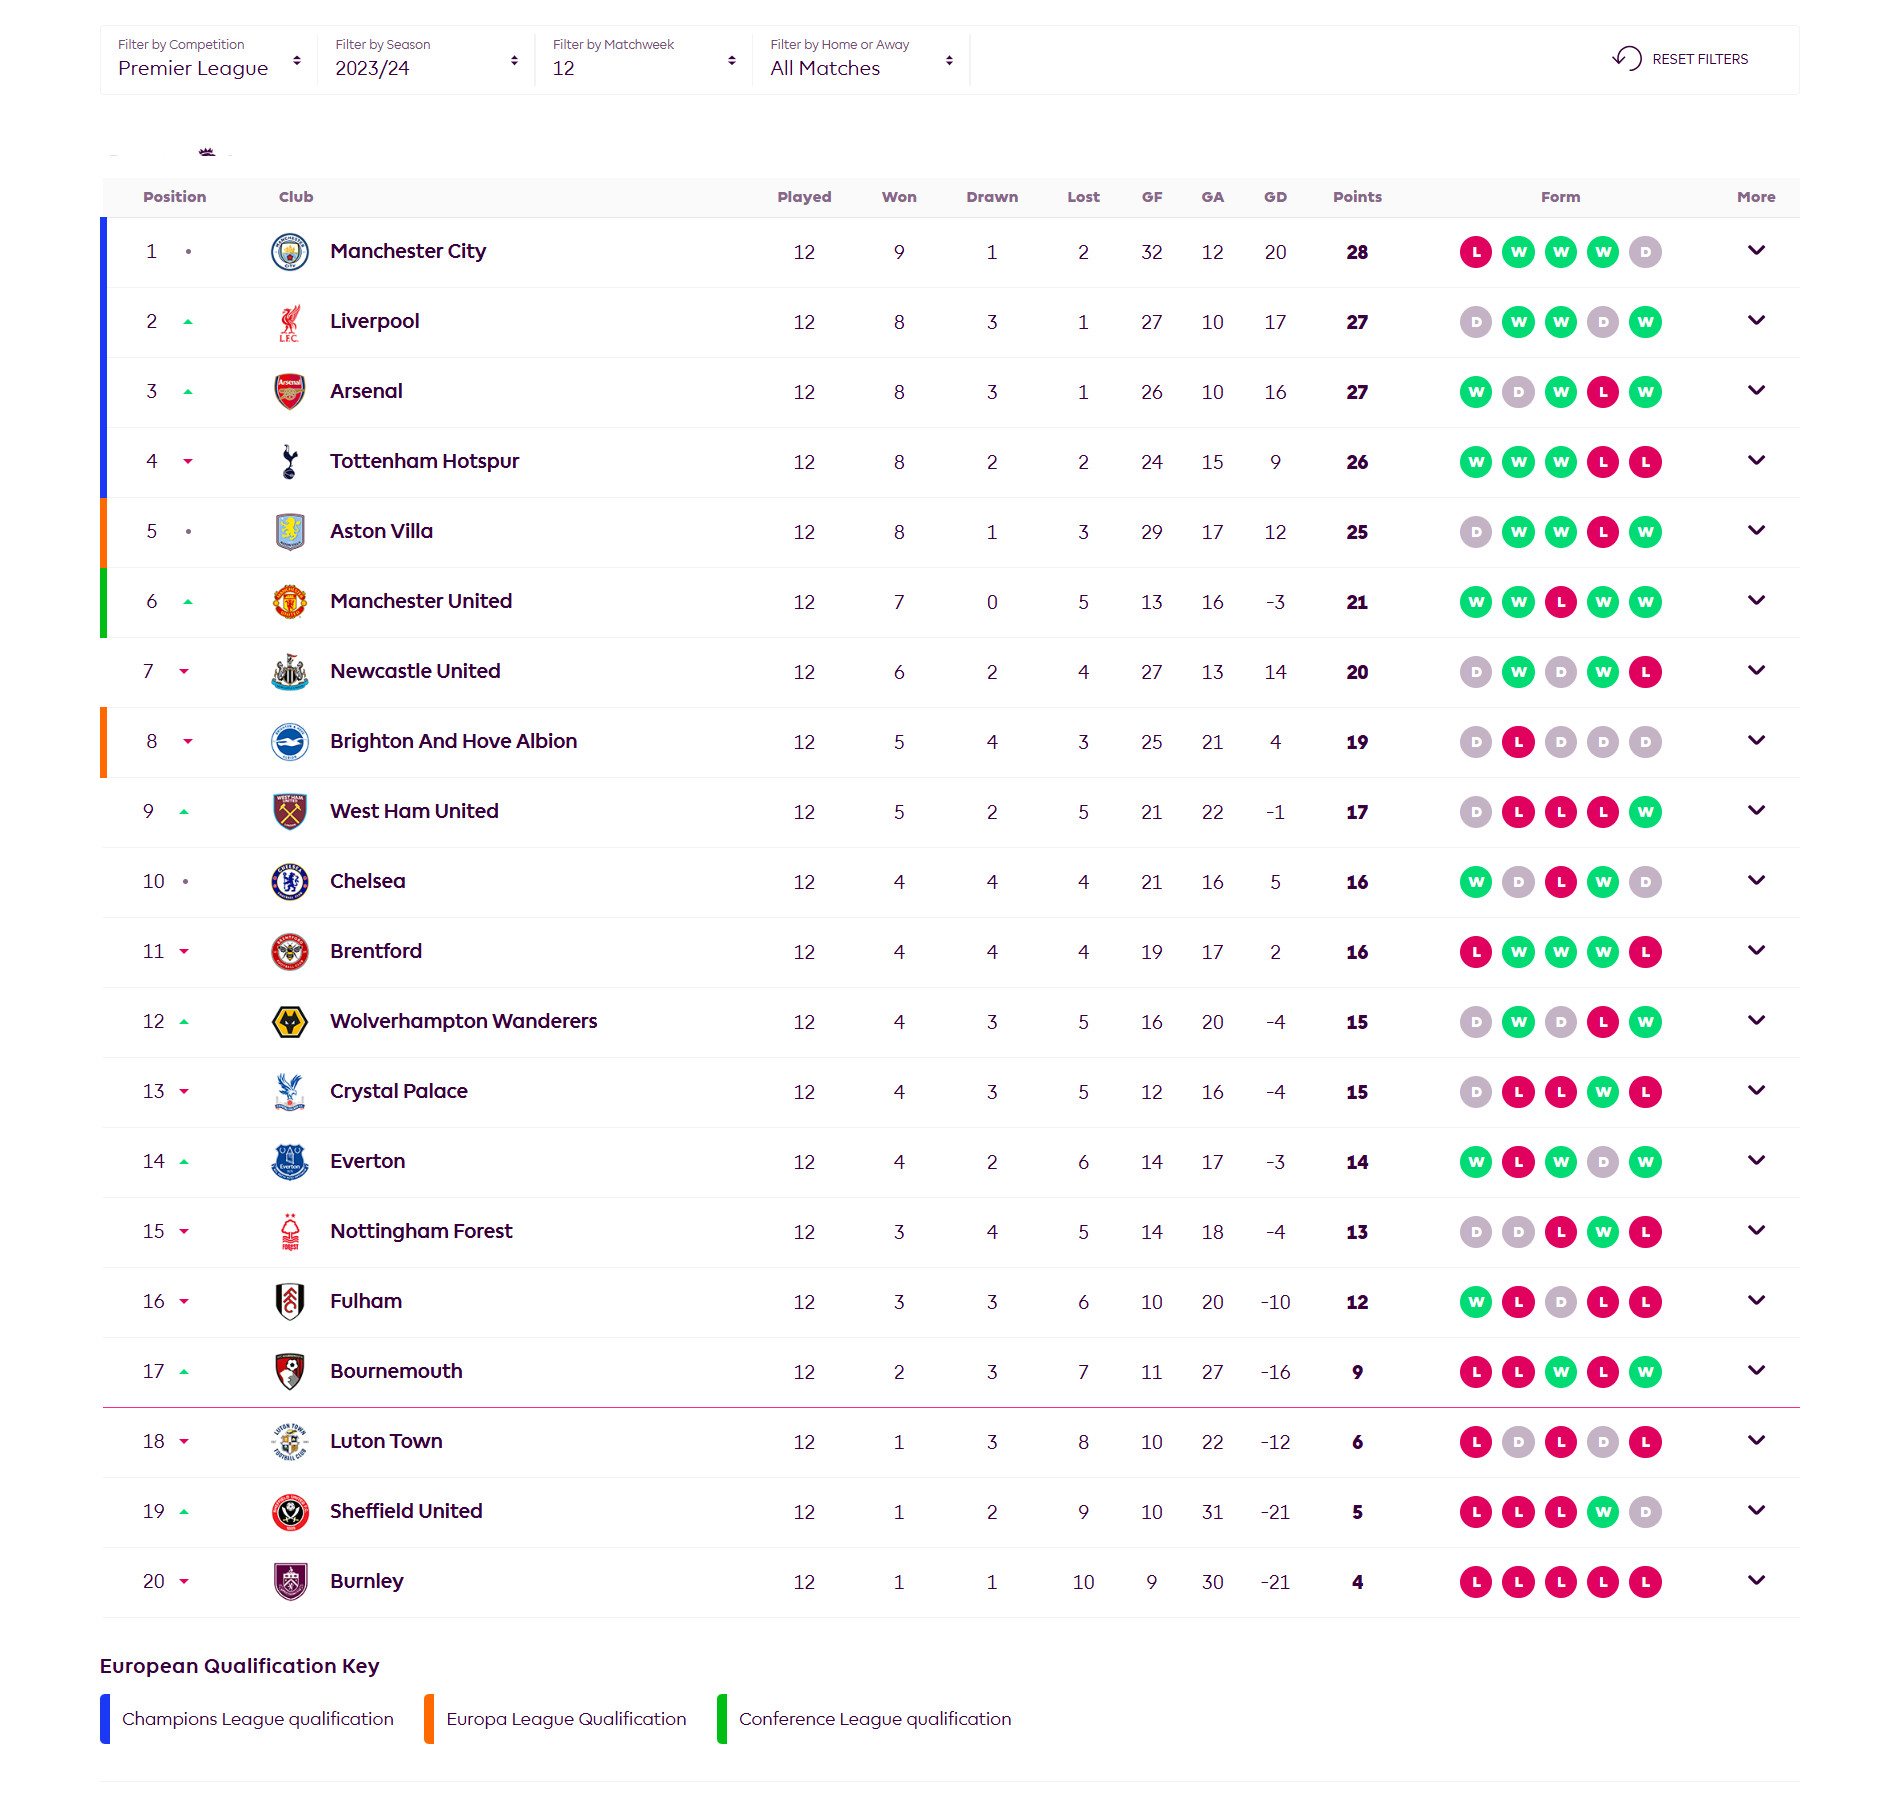

In [124]:
X_train, y_train, X_test, y_test = train_test_split(df_mid_table)

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
X_test_numeric = X_test.select_dtypes(include=['float64', 'int64'])

base_models = [
    ('svm', SVC(C=0.1, kernel='linear', gamma='scale', class_weight=None)),
    ('xgb', XGBClassifier(learning_rate=0.01, max_depth=5, n_estimators=50, subsample=0.8))
]

meta_model = LogisticRegression()

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stacking_clf.fit(X_train_numeric, y_train)

y_pred = stacking_clf.predict(X_test_numeric)

teams = df_mid_table['Team_norm'].unique()
points_table = {team: 0 for team in teams}

match_results = []
num_matches = len(y_pred)
print(len(y_pred))
for index in range(num_matches):
    row = X_test.iloc[index]
    team1 = row['Team_norm']
    team2 = row['Opponent_norm']
    result = y_pred[index]
    match_results.append((team1, team2, result))


for match in match_results:
    team1, team2, result = match

    if result == 1:
        points_table[team1] += 1
        points_table[team2] += 1
    elif result == 3:
        points_table[team1] += 3

points_df = pd.DataFrame(list(points_table.items()), columns=['Team', 'Points'])

points_df = points_df.sort_values(by='Points', ascending=False).reset_index(drop=True)

points_df['Status'] = 'Mid Table'

points_df.at[0, 'Status'] = 'Champion'

if len(points_df) > 3:
    points_df.loc[1:3, 'Status'] = 'Top 4'

if len(points_df) > 3:
    points_df.loc[len(points_df)-3:, 'Status'] = 'Relegated'

print("=== Points Table after 12 Matches Based on Predicted Outcomes from Stacking Classifier ===\n")

print(points_df)

240
=== Points Table after 12 Matches Based on Predicted Outcomes from Stacking Classifier ===

                Team  Points     Status
0     ManchesterCity      33   Champion
1          Liverpool      33      Top 4
2            Arsenal      24      Top 4
3            Chelsea      24      Top 4
4    NewcastleUnited      24  Mid Table
5            Everton      23  Mid Table
6         AstonVilla      22  Mid Table
7   NottinghamForest      21  Mid Table
8   ManchesterUnited      21  Mid Table
9           Brighton      20  Mid Table
10     Wolverhampton      19  Mid Table
11  TottenhamHotspur      18  Mid Table
12            Fulham      17  Mid Table
13     CrystalPalace      15  Mid Table
14       Bournemouth      15  Mid Table
15         Brentford      13  Mid Table
16     WestHamUnited      10  Mid Table
17         LutonTown       8  Relegated
18           Burnley       7  Relegated
19   SheffieldUnited       7  Relegated


# End